In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [4]:
print(df.dtypes)

Дата              str
Склад           int64
Контрагент        str
Номенклатура      str
Количество      int64
dtype: object


Проверяем формат столбцов

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Дата          301355 non-null  str  
 1   Склад         301355 non-null  int64
 2   Контрагент    301355 non-null  str  
 3   Номенклатура  301355 non-null  str  
 4   Количество    301355 non-null  int64
dtypes: int64(2), str(3)
memory usage: 20.0 MB
None


In [6]:
df["Дата"] = pd.to_datetime(df["Дата"])
print(df.dtypes)

Дата            datetime64[us]
Склад                    int64
Контрагент                 str
Номенклатура               str
Количество               int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

Сгруппируйте данные по дате, посчитайте количество продаж

In [7]:
grouped_df = df.groupby("Дата")["Количество"].sum()
print(grouped_df)

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64


Вывести несколько первых строк сгруппированных данных

In [8]:
grouped_df.head()

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64

Нарисуйте график продаж у `grouped_df`

<Axes: xlabel='Дата'>

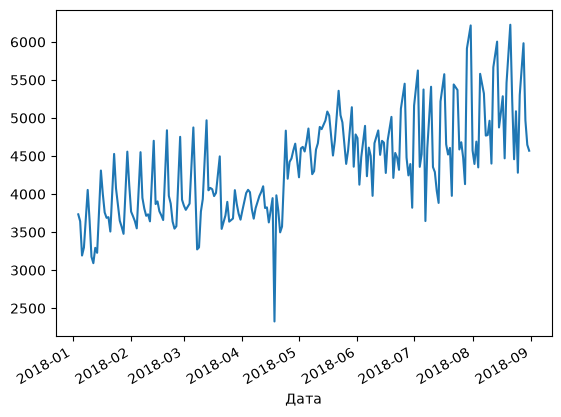

In [9]:
grouped_df.plot()

### Продажи в целом растут, но заметно колеблются. Самые высокие значения наблюдаются ближе к концу графика

Опишите что вы видите на графике. Ваша задача - максимально описать график

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
df.loc[df["Количество"].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
top_product = (df[(df["Склад"] == 3) &(df["Дата"].dt.month.isin([6, 7, 8])) &(df["Дата"].dt.dayofweek == 2)].groupby("Номенклатура")["Количество"].sum().idxmax())
print(top_product)

product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [26]:
weather = pd.read_csv("weather (2) (2) (1).csv",sep=";",decimal=",",header=0)
weather.columns = weather.columns.str.strip()
weather.head()

,Дата,T
0,31.08.2018,9.6
1,31.08.2018,11.3
2,31.08.2018,12.3
3,31.08.2018,13.2
4,31.08.2018,12.5


In [28]:
weather["Дата"] = pd.to_datetime(weather["Дата"],format="%d.%m.%Y")
weather["T"] = pd.to_numeric(weather["T"])
weather.head()

,Дата,T
0,2018-08-31,9.6
1,2018-08-31,11.3
2,2018-08-31,12.3
3,2018-08-31,13.2
4,2018-08-31,12.5


In [52]:
grouped_weather=weather.groupby("Дата")["T"].mean().reset_index()
grouped_weather

,Дата,T
0,2018-01-04,-13.0875
1,2018-01-05,-17.2500
2,2018-01-06,-14.1250
3,2018-01-07,-12.3375
4,2018-01-08,-15.4375
...,...,...
235,2018-08-27,12.2250
236,2018-08-28,14.1000
237,2018-08-29,14.0375
238,2018-08-30,14.1625


In [53]:
result = pd.merge(grouped_df, grouped_weather, on="Дата")
result.head()

,index,Дата,Количество,T
0,0,2018-01-04,3734,-13.0875
1,1,2018-01-05,3643,-17.2500
2,2,2018-01-06,3193,-14.1250
3,3,2018-01-07,3298,-12.3375
4,4,2018-01-09,4055,-7.3875


In [54]:
print(result.columns)

Index(['index', 'Дата', 'Количество', 'T'], dtype='str')


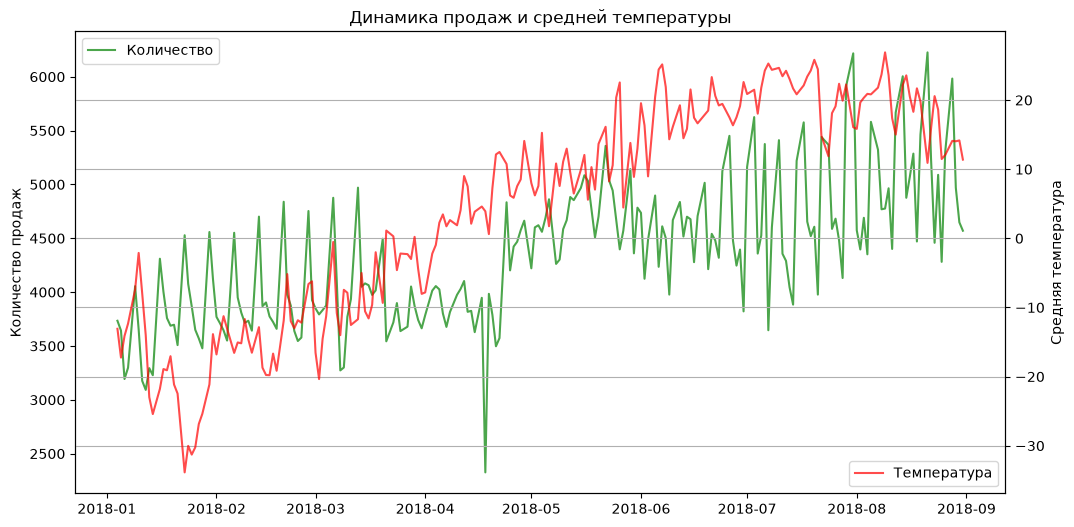

In [46]:
fig, ax=plt.subplots(figsize=(12, 6))
ax1=ax.twinx()
ax.plot(
result["Дата"],
result["Количество"],
color="green",
alpha=0.7,
label="Количество")
ax1.plot(
result["Дата"],
result["T"],
color="red",
alpha=0.7,
label="Температура")

ax.legend(loc="upper left")
ax1.legend(loc="lower right")

ax.set_ylabel("Количество продаж")
ax1.set_ylabel("Средняя температура")

plt.title("Динамика продаж и средней температуры")
plt.grid(True)
plt.show()

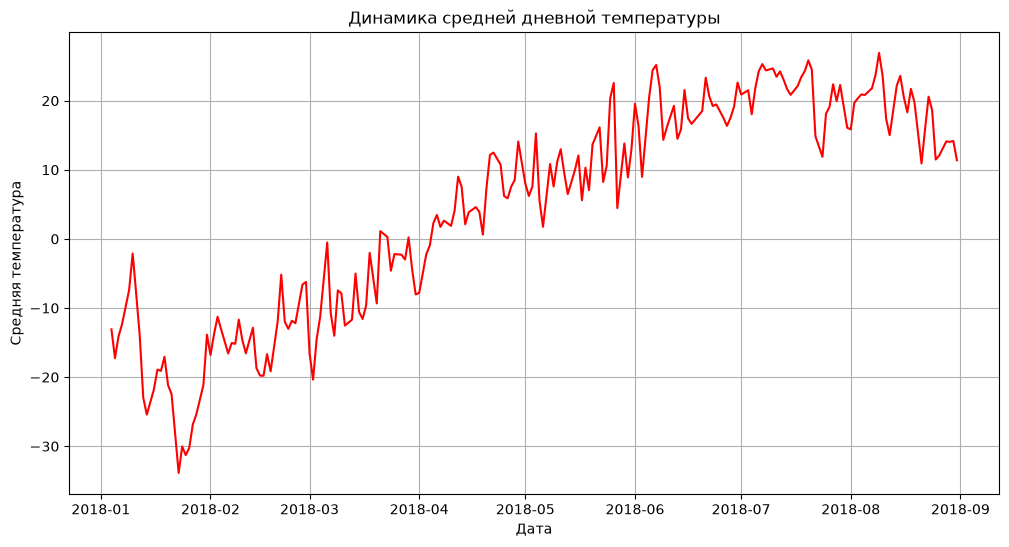

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(result["Дата"], result["T"], color="red")
plt.ylabel("Средняя температура")
plt.xlabel("Дата")
plt.grid(True)
plt.title("Динамика средней дневной температуры")

plt.show()

In [48]:
result = result.rename(columns={"Количество": "Количество продаж"})

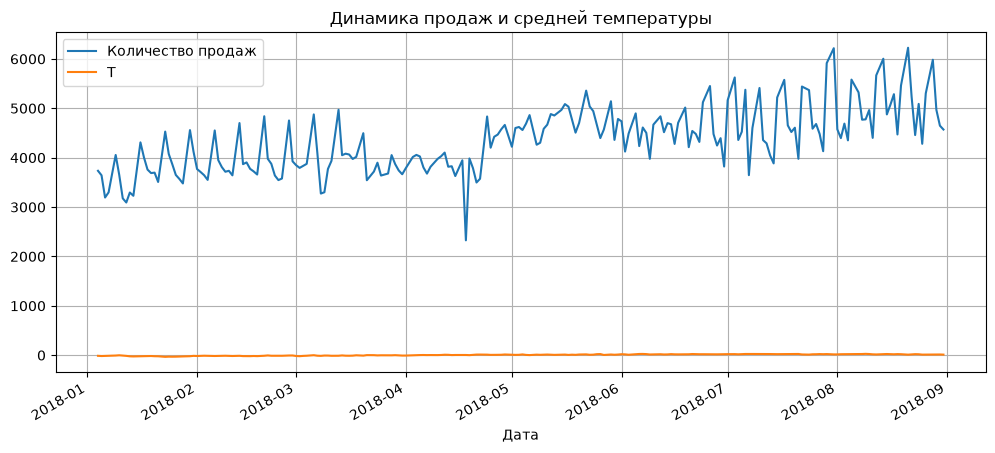

In [50]:
result.plot(
x="Дата",
y=["Количество продаж", "T"],
figsize=(12, 5)
)

plt.grid(True)
plt.title("Динамика продаж и средней температуры")
plt.show()